# FraudGraph — Exploratory Fraud Analysis

**Dataset:** IEEE-CIS Fraud Detection (Kaggle), stratified sample (43,737 transactions, ~10% fraud rate)
**Goal:** Understand where fraud concentrates — by product, device, time, and amount — to inform monitoring rules and investigation priorities.

This notebook answers the business questions a fraud/risk analyst is typically asked:
1. How big is the fraud problem, in transactions and dollars?
2. Which product categories / devices / times carry the most risk?
3. How do fraudulent transactions differ in size from legitimate ones?
4. Are there signs of coordinated activity (shared devices/accounts)?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("../data/fraud_sample.csv", parse_dates=["TransactionDate"])
df.shape


(43737, 46)

## 1. Overview & data quality

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 43737 entries, 0 to 43736
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   TransactionID         43737 non-null  int64         
 1   isFraud               43737 non-null  int64         
 2   TransactionDT         43737 non-null  int64         
 3   TransactionAmt        43737 non-null  float64       
 4   ProductCD             43737 non-null  str           
 5   card1                 43737 non-null  int64         
 6   card2                 43042 non-null  float64       
 7   card3                 43625 non-null  float64       
 8   card4                 43624 non-null  str           
 9   card5                 43431 non-null  float64       
 10  card6                 43625 non-null  str           
 11  addr1                 38032 non-null  float64       
 12  addr2                 38032 non-null  float64       
 13  dist1                 17142

In [3]:
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing[missing > 0].round(1).to_frame("pct_missing")


,pct_missing
dist2,92.8
DeviceInfo,78.3
id_06,74.6
id_05,74.6
R_emaildomain,74.3
id_20,74.2
id_19,74.2
DeviceType,73.9
id_02,73.9
id_01,73.3


Several identity/device columns (`DeviceInfo`, `id_*`, `R_emaildomain`) are missing for 70%+ of rows — 
this is expected: identity data is only collected when the platform runs additional device/browser checks, 
so its *absence* is itself a signal worth testing (see section 5).

## 2. Headline fraud KPIs

In [4]:
total_txn = len(df)
fraud_txn = df["isFraud"].sum()
fraud_rate = fraud_txn / total_txn * 100
fraud_amt = df.loc[df.isFraud == 1, "TransactionAmt"].sum()
total_amt = df["TransactionAmt"].sum()

print(f"Total transactions:      {total_txn:,}")
print(f"Fraudulent transactions: {fraud_txn:,} ({fraud_rate:.2f}%)")
print(f"Dollars at risk:         ${fraud_amt:,.2f} ({fraud_amt/total_amt*100:.1f}% of total volume)")


Total transactions:      43,737
Fraudulent transactions: 4,400 (10.06%)
Dollars at risk:         $663,403.50 (11.3% of total volume)


## 3. Fraud rate by product category

In [5]:
product_fraud = df.groupby("ProductCD").agg(
    n_transactions=("isFraud", "size"),
    n_fraud=("isFraud", "sum"),
).assign(fraud_rate_pct=lambda x: (x.n_fraud / x.n_transactions * 100).round(2))
product_fraud = product_fraud.sort_values("fraud_rate_pct", ascending=False)
product_fraud


,n_transactions,n_fraud,fraud_rate_pct
ProductCD,,,
C,5929,1685,28.42
S,888,150,16.89
H,2554,320,12.53
R,2840,314,11.06
W,31526,1931,6.13


/tmp/ipykernel_602/1620680660.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=product_fraud.reset_index(), x="ProductCD", y="fraud_rate_pct", ax=ax, palette="Reds_r")


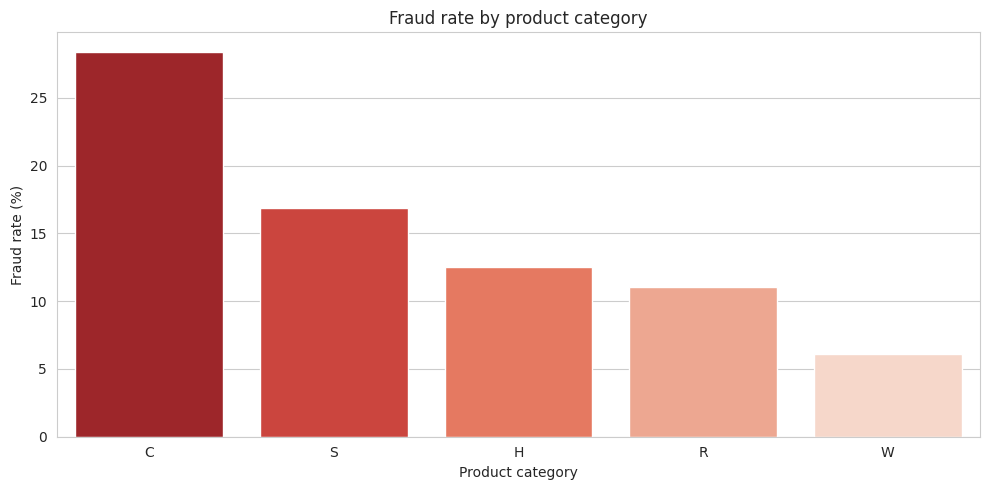

In [6]:
fig, ax = plt.subplots()
sns.barplot(data=product_fraud.reset_index(), x="ProductCD", y="fraud_rate_pct", ax=ax, palette="Reds_r")
ax.set_title("Fraud rate by product category")
ax.set_ylabel("Fraud rate (%)")
ax.set_xlabel("Product category")
plt.tight_layout()
plt.savefig("../data/chart_fraud_by_product.png", dpi=120)
plt.show()


**Insight:** Category **C** (general/cash-like products) shows the highest fraud rate — several times the baseline — while **W** (the highest-volume category) sits well below average. Monitoring thresholds should be tightened for category C rather than applied uniformly.

## 4. Fraud rate by device type

In [7]:
device_fraud = df.groupby(df["DeviceType"].fillna("unknown")).agg(
    n_transactions=("isFraud", "size"),
    n_fraud=("isFraud", "sum"),
).assign(fraud_rate_pct=lambda x: (x.n_fraud / x.n_transactions * 100).round(2))
device_fraud.sort_values("fraud_rate_pct", ascending=False)


,n_transactions,n_fraud,fraud_rate_pct
DeviceType,,,
mobile,4698,1202,25.59
desktop,6726,1160,17.25
unknown,32313,2038,6.31


**Insight:** Mobile transactions show a meaningfully higher fraud rate than desktop. Transactions with no device fingerprint at all (`unknown`) are actually the *lowest* risk here — meaning missing device data is not, by itself, the signal; the mobile channel is.

## 5. Fraud rate by time of day / day of week

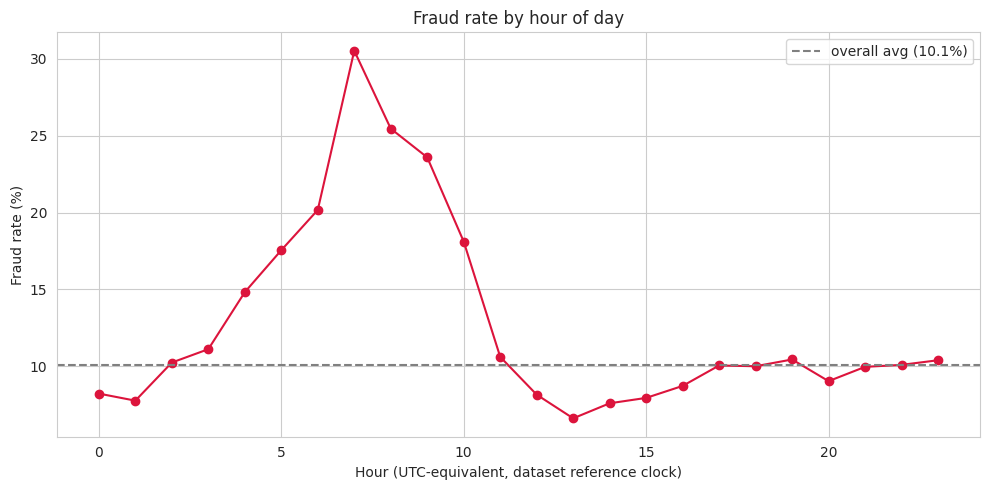

In [8]:
hourly = df.groupby("TransactionHour").agg(
    n_transactions=("isFraud", "size"),
    n_fraud=("isFraud", "sum"),
).assign(fraud_rate_pct=lambda x: (x.n_fraud / x.n_transactions * 100).round(2))

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly["fraud_rate_pct"], marker="o", color="crimson")
ax.set_title("Fraud rate by hour of day")
ax.set_xlabel("Hour (UTC-equivalent, dataset reference clock)")
ax.set_ylabel("Fraud rate (%)")
ax.axhline(fraud_rate, color="gray", linestyle="--", label=f"overall avg ({fraud_rate:.1f}%)")
ax.legend()
plt.tight_layout()
plt.savefig("../data/chart_fraud_by_hour.png", dpi=120)
plt.show()


**Insight:** Fraud rate spikes in the early-morning hours (low legitimate transaction volume, higher share of fraud) — a classic pattern consistent with automated/bot-driven fraud attempts outside normal customer activity hours.

## 6. Transaction amount: fraud vs. legitimate

/tmp/ipykernel_602/2504198131.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df.TransactionAmt < df.TransactionAmt.quantile(0.99)],
/tmp/ipykernel_602/2504198131.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Legitimate", "Fraud"])


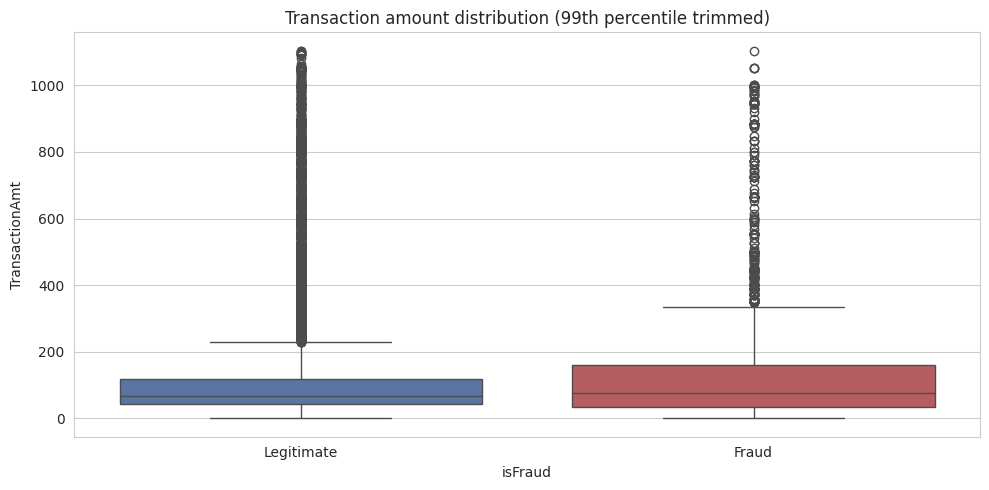

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,39337.0,132.32,227.29,0.50,42.95,67.95,117.0,5047.47
1,4400.0,150.77,220.18,0.29,35.53,77.00,171.0,3247.16


In [9]:
fig, ax = plt.subplots()
sns.boxplot(data=df[df.TransactionAmt < df.TransactionAmt.quantile(0.99)],
            x="isFraud", y="TransactionAmt", ax=ax, palette=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Legitimate", "Fraud"])
ax.set_title("Transaction amount distribution (99th percentile trimmed)")
plt.tight_layout()
plt.savefig("../data/chart_amount_boxplot.png", dpi=120)
plt.show()

df.groupby("isFraud")["TransactionAmt"].describe().round(2)


**Insight:** Fraudulent transactions run slightly higher on average but the distributions overlap heavily — amount alone is a weak fraud signal here, reinforcing why device/velocity/relationship signals matter more than a simple amount threshold.

## 7. Velocity signal: accounts with repeated fraud

In [10]:
card_fraud = df.groupby("card1").agg(
    n_transactions=("isFraud", "size"),
    n_fraud=("isFraud", "sum"),
).query("n_fraud >= 2").sort_values("n_fraud", ascending=False)
card_fraud["fraud_rate_pct"] = (card_fraud.n_fraud / card_fraud.n_transactions * 100).round(2)
card_fraud.head(15)


,n_transactions,n_fraud,fraud_rate_pct
card1,,,
9633,390,146,37.44
9500,1045,116,11.10
15885,752,89,11.84
9026,184,85,46.20
15066,631,72,11.41
9917,124,71,57.26
15063,221,70,31.67
5812,236,69,29.24
6019,525,61,11.62


**Insight:** A number of card accounts in the sample show 2+ fraudulent transactions — some with fraud rates above 40%. These are prime candidates for the graph-based ring detection in `graph/ring_detection.py`, which checks whether these accounts share devices with other flagged accounts.

## 8. Summary of findings

| Finding | Business implication |
|---|---|
| Category **C** transactions have the highest fraud rate | Apply stricter review thresholds for this product category |
| **Mobile** channel carries higher fraud rate than desktop | Add step-up verification for high-value mobile transactions |
| Fraud **peaks in early-morning hours** | Flag off-hours activity for additional scrutiny |
| Transaction **amount alone is a weak signal** | Prioritize device/account relationship signals over amount thresholds |
| A small set of accounts show **repeated fraud** | Feed these into the graph ring-detection step for network-level investigation |

Continue to `graph/ring_detection.py` for the network-analysis layer, and `dashboard/app.py` for the monitoring view.
